#  Examen finale - Python pour l'analyse de données 

---
# Exercice 1 - Nettoyage des données clients 
---

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Q1 
# Lecture du fichier Excel
df = pd.read_csv("ventes_chocolux.csv")
df.sample(5)

,commande_id,client_id,nom_client,age,genre,ville,produit_id,nom_produit,type_chocolat,quantite,prix_unitaire,date_commande,remarques_clients
361,CMD0361,C140,Benoît Poirier,26,F,nantes,P002,Chocolux Lait Noisettes,lait,3,4.8,2025-02-13,NaN
199,CMD0200,C182,Josette Léger,30,F,Lyon,P004,Chocolux Noir Fleur de Sel,noir,3,6.2,2024-12-25,NaN
39,CMD0040,C105,Timothée Leblanc,18,F,Lille,P003,Chocolux Blanc Vanille,blanc,3,4.5,2024-12-02,NaN
0,CMD0001,C194,JOSEPH TORRES,24,M,toulouse,P001,Chocolux Noir 80%,noir,1,5.5,2024-12-30,NaN
5,CMD0006,C110,Gérard de la Daniel,32,M,Marseille,P002,Chocolux Lait Noisettes,lait,3,4.8,2025-01-20,NaN


In [3]:
# Infos générales 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   commande_id        521 non-null    object 
 1   client_id          521 non-null    object 
 2   nom_client         521 non-null    object 
 3   age                521 non-null    object 
 4   genre              521 non-null    object 
 5   ville              506 non-null    object 
 6   produit_id         521 non-null    object 
 7   nom_produit        521 non-null    object 
 8   type_chocolat      521 non-null    object 
 9   quantite           521 non-null    int64  
 10  prix_unitaire      521 non-null    float64
 11  date_commande      521 non-null    object 
 12  remarques_clients  49 non-null     object 
dtypes: float64(1), int64(1), object(11)
memory usage: 53.0+ KB


In [4]:
# statistiques sur les colonnes numériques 
df.describe(include="number").round(2)

,quantite,prix_unitaire
count,521.00,521.00
mean,2.97,5.22
std,1.42,0.56
min,1.00,4.50
25%,2.00,4.80
50%,3.00,5.00
75%,4.00,5.50
max,5.00,6.20


In [5]:
df.describe(include="all")

,commande_id,client_id,nom_client,age,genre,ville,produit_id,nom_produit,type_chocolat,quantite,prix_unitaire,date_commande,remarques_clients
count,521,521,521,521,521,506,521,521,521,521.000000,521.000000,521,49
unique,500,100,503,49,2,16,5,5,3,NaN,NaN,118,4
top,CMD0143,C102,Constance Buisson-Collin,53,F,Paris,P002,Chocolux Lait Noisettes,noir,NaN,NaN,2025-02-11,mauvais
freq,3,14,3,22,262,123,159,159,245,NaN,NaN,27,21
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.967370,5.223800,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.418589,0.559094,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,4.500000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,4.800000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,5.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,5.500000,NaN,NaN


In [6]:
# valeurs manquantes 
df.isna().sum(axis = 0)

commande_id            0
client_id              0
nom_client             0
age                    0
genre                  0
ville                 15
produit_id             0
nom_produit            0
type_chocolat          0
quantite               0
prix_unitaire          0
date_commande          0
remarques_clients    472
dtype: int64


--- Analyse des outliers pour quantite ---
Nombre de valeurs aberrantes détectées : 0


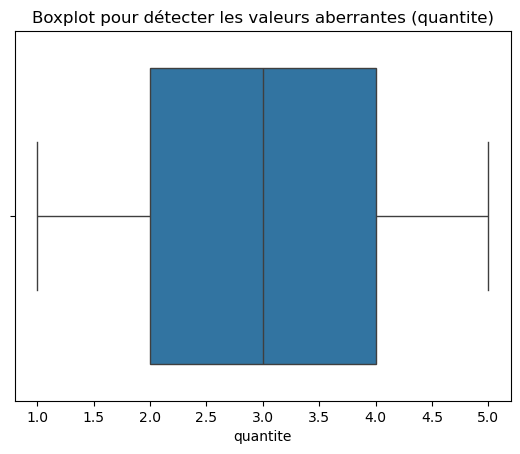


--- Analyse des outliers pour prix_unitaire ---
Nombre de valeurs aberrantes détectées : 0


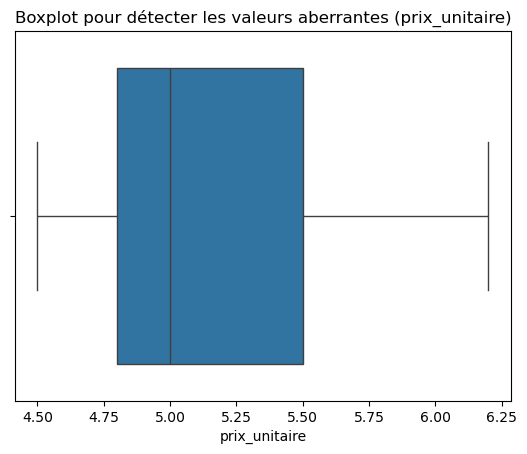

In [7]:
# analyse des valeurs aberrantes/outliers avec la méthode IQR
# Liste des colonnes numériques concernées par des valeurs manquantes
colonnes_a_traiter = ['quantite', 'prix_unitaire']

for colonne in colonnes_a_traiter:    
    print(f"\n--- Analyse des outliers pour {colonne} ---")
    
    #  Calcul des quartiles
    Q1 = df[colonne].quantile(0.25)      # Premier quartile (25 %)
    Q3 = df[colonne].quantile(0.75)      # Troisième quartile (75 %)
    IQR = Q3 - Q1                        # IQR = écart interquartile (Q3 - Q1)
    
    # Détection des valeurs aberrantes (hors des bornes IQR)
    outliers = df[
        (df[colonne] < Q1 - 1.5 * IQR) |  # Trop petit
        (df[colonne] > Q3 + 1.5 * IQR)    # Trop grand
    ]
    
    #  Affichage du nombre d'outliers détectés
    print(f"Nombre de valeurs aberrantes détectées : {len(outliers)}")
    
    # Visualisation avec un boxplot pour mieux repérer les outliers
    sns.boxplot(x=df[colonne])
    plt.title(f"Boxplot pour détecter les valeurs aberrantes ({colonne})")
    plt.show()

In [8]:
# Détection des doublons
print("\n Nombre de doublons :", df.duplicated().sum())


 Nombre de doublons : 14


In [9]:
# voir des valeurs uniques dans l'age 
df['age'].unique()

array(['24', '53', '28', '56', '58', '32', '35', '62', '43', '49', '52',
       '50', '45', '61', '51', '33', '59', '55', '22', '48', '21', '26',
       '42', '60', '38', '29', '31', '18', '40', '57', '19', '64', '30',
       '46', '27', '47', '63', '34', '20', '39', '23', '36',
       'trente-deux', '41', '25', '65', '37', '44', '54'], dtype=object)

###  Commentaire générales 
Il y a 521 lignes et 13 colonnes. 

Les colonnes catégorielles sont au format object. 
les colonnes quantité et prix_unitaire sont au format numérique (`int64`, `float64`)

En regardant les statistiques sur les colonnes numériques, les colonnes quantité et prix_unitaire présentent des valeurs relativement faibles. 
Pour la colonne quantite, la valeurs sont bien étalés avec une minimum de 1, maximum de 5 et une moyenne de 3. 
Pour la colonne prix_unitaire également la dispersion est faible avec un écart-type de 0.56. 

Pas de valeurs aberrantes pour les colonnes quantite et prix_unitaire. 

###  Problèmes potentiels avec les données 

Pour a colonne age, on a une valeur incohérente : trente-deux en texte au lieu de 32. 

date_commande est au format object, il faut la convertir au format datetime64
L'age est au format object, il faut le convertir au format numérique 
Les colonnes avec peu de valeurs uniques, on va les convertir au format categorie. 

Il y a des valeurs manquantes pour deux colonnes : ville et remarques_clients 
pour la colonne ville, il manque 15 valeurs. 
Pour la colonne remarques_clients, il manque 472 valeurs. 

Il existe 14 lignes de doublons. 

###  Q2 . Plan de nettoyage
1.  Remplacer le texte 'trente-deux' en 32 pour la colonne age
2.  Conversions de types : date_commmande au format datetime64 et l'age au format numérique.
3.  Suppression des doublons
4.  Traitement des valeurs manquantes

In [10]:
# Q3 
# remplacer trente-deux en texte par 32 
df['age'] = df['age'].replace({'trente-deux': '32'})
# vérification des valeurs uniques 
df['age'].unique()

array(['24', '53', '28', '56', '58', '32', '35', '62', '43', '49', '52',
       '50', '45', '61', '51', '33', '59', '55', '22', '48', '21', '26',
       '42', '60', '38', '29', '31', '18', '40', '57', '19', '64', '30',
       '46', '27', '47', '63', '34', '20', '39', '23', '36', '41', '25',
       '65', '37', '44', '54'], dtype=object)

In [11]:
# 1. conversion de type 

# date en datetime
df['date_commande'] = pd.to_datetime(df['date_commande'], errors='coerce', format='%Y-%m-%d')
# age en numerique 
df['age'] = pd.to_numeric(df['age'], errors='coerce')
# conversion en categorie
df['genre'] = df['genre'].astype('category')
df['produit_id'] = df['produit_id'].astype('category')
df['nom_produit'] = df['nom_produit'].astype('category')
df['type_chocolat'] = df['type_chocolat'].astype('category')
df['ville'] = df['ville'].astype('category')
df['remarques_clients'] = df['remarques_clients'].astype('category')
# vérification des modifications des types 
df.dtypes

commande_id                  object
client_id                    object
nom_client                   object
age                           int64
genre                      category
ville                      category
produit_id                 category
nom_produit                category
type_chocolat              category
quantite                      int64
prix_unitaire               float64
date_commande        datetime64[ns]
remarques_clients          category
dtype: object

In [12]:
# gestion des valeurs doublons 

# affichage de nombre de doublons 
print("\n Nombre de doublons :", df.duplicated().sum())
# Suppression des doublons
df = df.drop_duplicates()
# vérification des doublons 
print("\n Nombre de doublons après suppresion:", df.duplicated().sum())


 Nombre de doublons : 14

 Nombre de doublons après suppresion: 0


In [13]:
# Gestion des valeurs manquantes : colonne ville 

# vérification des valeurs uniques et uniformisation 
df['ville'].unique()
df['ville'] = df['ville'].str.lower().str.strip() 
df['ville'].unique()
# affichage optional des valeurs manquantes 
df[df['ville'].isna()]
# copy de df 
df_nettoyage = df.copy()
# il y a 8 uniques villes et la ville de paris est fréquent 135 fois donc on va remplacer les valeurs manquates par le mode : paris
ville_mode = df_nettoyage['ville'].mode()
df_nettoyage['ville'] = df_nettoyage['ville'].fillna( ville_mode[0])

In [14]:
# Gestion des valeurs manquantes : colonne remarques_clients

# comme il existe beaucoup de valeurs manquantes pour cette colonne, la méthode choisie est de remplir toutes les lignes 
# manquantes comme " Non renseigné" 

df_nettoyage['remarques_clients'] = df_nettoyage['remarques_clients'].cat.add_categories('Non renseigné')
df_nettoyage['remarques_clients'] = df_nettoyage['remarques_clients'].fillna('Non renseigné')

# vérification des valeur manquantes 
df_nettoyage.isna().sum(axis = 0)

commande_id          0
client_id            0
nom_client           0
age                  0
genre                0
ville                0
produit_id           0
nom_produit          0
type_chocolat        0
quantite             0
prix_unitaire        0
date_commande        0
remarques_clients    0
dtype: int64

In [15]:
# Q4 Bonus : Créer une fonction nettoyer_texte(colonne) qui : enlève les espaces inutiles, passe en minuscules, capitalise la première lettre de chaque mot.
def nettoyer_texte(colonne):
    return colonne.str.strip().str.lower().str.replace(r'\s+', ' ', regex=True).str.title()

---
# Exercice 2 - Analyse des ventes
---

In [16]:
# Q5 
# Création de la colonne chiffre_affaires
df_nettoyage['chiffre_affaires'] = df_nettoyage['quantite']*df_nettoyage['prix_unitaire']
df_nettoyage.sample(5)

,commande_id,client_id,nom_client,age,genre,ville,produit_id,nom_produit,type_chocolat,quantite,prix_unitaire,date_commande,remarques_clients,chiffre_affaires
337,CMD0338,C131,Maurice Fischer,37,M,marseille,P001,Chocolux Noir 80%,noir,1,5.5,2025-02-26,Non renseigné,5.5
70,CMD0071,C144,ALAIN RICHARD,32,M,lille,P003,Chocolux Blanc Vanille,blanc,1,4.5,2025-02-18,Non renseigné,4.5
91,CMD0092,C199,MATTHIEU JOURDAN,51,F,marseille,P002,Chocolux Lait Noisettes,lait,5,4.8,2025-02-26,Non renseigné,24.0
405,CMD0405,C188,Océane Pascal,57,F,paris,P002,Chocolux Lait Noisettes,lait,2,4.8,2025-02-17,Non renseigné,9.6
431,CMD0431,C106,Anastasie Girard,65,F,bordeaux,P004,Chocolux Noir Fleur de Sel,noir,1,6.2,2025-01-16,Non renseigné,6.2


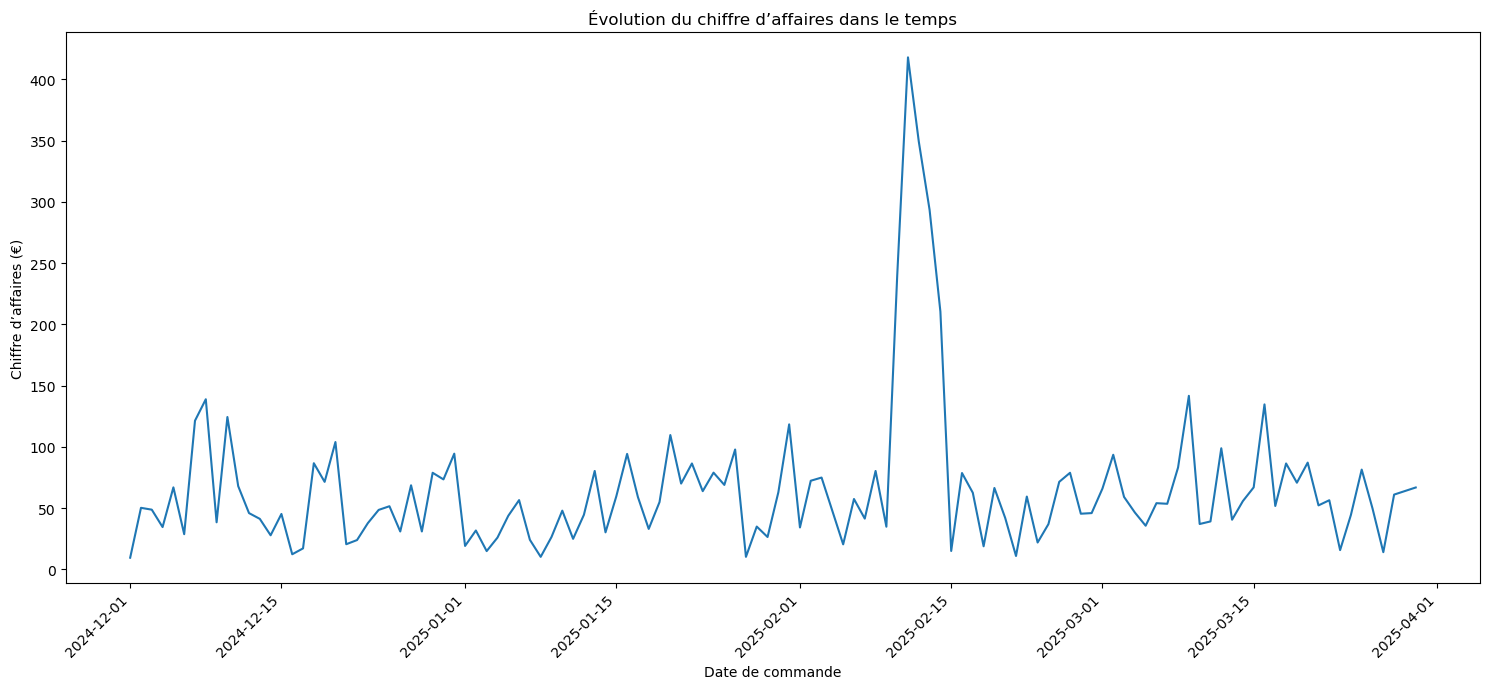

In [17]:
# Groupement du chiffre d'affaires par date
ca_par_date_de_commande = df_nettoyage.groupby('date_commande')['chiffre_affaires'].sum()

# tri par date 
ca_par_date_de_commande_sorted = ca_par_date_de_commande.sort_index()

# Tracer le graphique
plt.figure(figsize=(15, 7))
ca_par_date_de_commande_sorted.plot(kind='line')  
plt.title('Évolution du chiffre d’affaires dans le temps')
plt.xlabel('Date de commande')
plt.ylabel('Chiffre d’affaires (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

On remarque qu'il y un pic de Chiffres d'affaires entre juste avant le 15 Févirier

In [18]:
# Q6 
print(" --- CA par mois : --- ")
ca_par_mois= df_nettoyage.groupby(df['date_commande'].dt.to_period('M'))['chiffre_affaires'].sum()
ca_par_mois

# la période avec la plus forte croissance est le mois de Février 

 --- CA par mois : --- 


date_commande
2024-12    1742.8
2025-01    1612.2
2025-02    2581.9
2025-03    1845.7
Freq: M, Name: chiffre_affaires, dtype: float64

In [19]:
#Q7
print("5 journées ayant généré le plus de chiffre d’affaires : ")
ca_par_date_de_commande_sorted.sort_values(ascending=False).head(5)

# On remarque qu'il y une pic de Chiffres d'affaires entre le 11 Février et le 14 Février ce qui correspont à la fête de Saint-Valentin. 
# ce qui explique que la période forte où l'entreprise génére plus de CA est la période de saint valentin. 

5 journées ayant généré le plus de chiffre d’affaires : 


date_commande
2025-02-11    417.9
2025-02-12    349.2
2025-02-13    293.4
2025-02-10    239.3
2025-02-14    210.4
Name: chiffre_affaires, dtype: float64

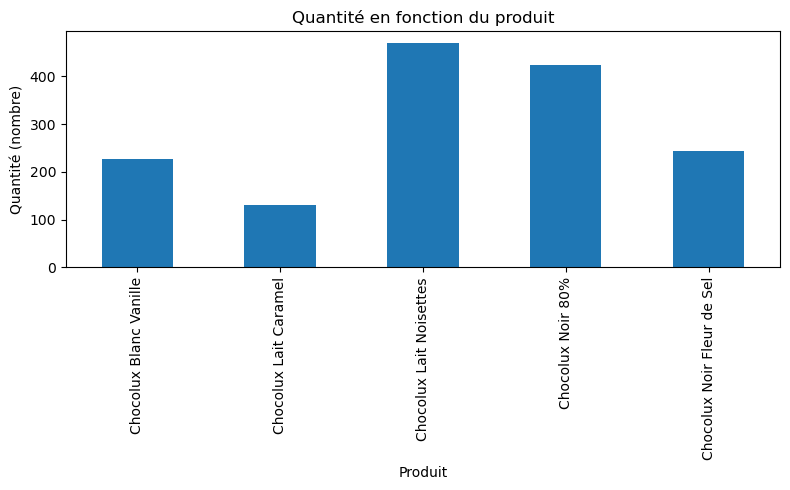

In [20]:
# Q8
# top 5 des produits les plus vendu en quantite  

# Groupement du quantité par produit 
qte_par_produit = df_nettoyage.groupby('nom_produit', observed=True)['quantite'].sum()

# Tracer le graphique
plt.figure(figsize=(8, 5))
qte_par_produit.plot(kind='bar')  
plt.title('Quantité en fonction du produit')
plt.xlabel('Produit')
plt.ylabel('Quantité (nombre)')
plt.tight_layout()
plt.show()

# Analyse des résultats 
# le produit le plus vendu est chocolux Lait Noisettes (471) ensuite Chocolux noir 80% (425) 
# Chocolux noir fleur de Sel est en 3ème position avec 244 produits vendus et suivi par chocolux Blan vanille est en avant dernière position (227). 
# le produit le mois vendu est le chocolux lait Caramel (130).  

In [21]:
# Q9 
# 3 villes les plus performantes en chiffre d’affaires total.

# Groupement du chiffre d'affaires par ville
ca_par_ville = df_nettoyage.groupby('ville')['chiffre_affaires'].sum()

# tri par CA 
ca_par_ville_sorted = ca_par_ville.sort_values(ascending=False)

# Affichage du résultat
print(f"Les 3 villes les plus performantes en chiffre d'affaires sont : {ca_par_ville_sorted.index[0]}, {ca_par_ville_sorted.index[1]} et {ca_par_ville_sorted.index[2]}")

Les 3 villes les plus performantes en chiffre d'affaires sont : paris, lille et marseille


In [22]:
# Q10 
# Calculer la dépense moyenne par client.

print("dépense moyenne par client : ")
# Regroupement par client_id 
depense_moy_par_client = df_nettoyage.groupby('client_id')['chiffre_affaires'].mean().round(2)
depense_moy_par_client

dépense moyenne par client : 


client_id
C100    18.74
C101    13.30
C102    10.96
C103    15.86
C104    14.52
        ...  
C195    24.00
C196    13.80
C197    17.20
C198    14.97
C199    20.03
Name: chiffre_affaires, Length: 100, dtype: float64

In [23]:
# le nombre de clients ayant dépensé plus de 100 €

# regroupement par client_id
depense_tot_par_client = df_nettoyage.groupby('client_id')['chiffre_affaires'].sum()
# selectionner seulement des clients ayant dépensé plus que 100 
clients_au_dessus_de_100 = depense_tot_par_client[depense_tot_par_client > 100]
# Afficher le nombre de clients
nombre_clients = clients_au_dessus_de_100.count()
print(f"Nombre de clients ayant dépensé plus de 100 € : {nombre_clients}")

Nombre de clients ayant dépensé plus de 100 € : 27


---
# Exercice 3 - Création d'une fonction d’analyse stratégique
---

In [24]:
# Q11
#Créer une fonction evaluer_performance(ca, nb_clients) qui retourne :
#•Blockbuster si CA ≥ 5000 € et clients ≥ 50
#•Niche rentable si CA ≥ 5000 € mais clients < 50
#•Produit prometteur si 1000 € ≤ CA < 5000 € et clients ≥ 20
#•À retravailler dans tous les autres cas

def evaluer_performance(ca, nb_clients) : 
    if ca >= 5000 and nb_clients >= 50 : 
        return 'Blockbuster'
    elif ca >= 5000 and nb_clients < 50 : 
        return 'Niche rentable'
    elif ca >= 1000 and ca < 5000 and  nb_clients >= 20 : 
        return 'Produit prometteur'
    else : 
        return 'À retravailler'

In [25]:
# Q12
# Calcule le chiffre d’affaires total pour chaque produit
ca_tot_par_produit = df_nettoyage.groupby('nom_produit', observed=True)['chiffre_affaires'].sum()
ca_tot_par_produit

# le nombre de clients distincts pour chaque produit
client_count_produit  = df.groupby('nom_produit', observed=True)['client_id'].nunique()
client_count_produit 

# puis regroupe ces deux résultats dans un même tableau appelé produit_stats.
produit_stats = pd.DataFrame({
    'chiffre_affaires_total': ca_tot_par_produit,
    'nombre_clients_distincts': client_count_produit
})

# Afficher le tableau
produit_stats

,chiffre_affaires_total,nombre_clients_distincts
nom_produit,,
Chocolux Blanc Vanille,1021.5,49
Chocolux Lait Caramel,650.0,35
Chocolux Lait Noisettes,2260.8,74
Chocolux Noir 80%,2337.5,80
Chocolux Noir Fleur de Sel,1512.8,58


In [26]:
# Q13
# Appliquer la fonction evaluer_performance sur chaque ligne pour créer la colonne statut_produit.
produit_stats['statut_produit'] = produit_stats.apply(
    lambda row: evaluer_performance(row['chiffre_affaires_total'], row['nombre_clients_distincts']),
    axis=1
)

In [27]:
# Q14
# affichage des produits à retravailler 

print('le(s) produit(s) à retravailler : ') 
produit_stats[produit_stats['statut_produit'] == 'À retravailler']

le(s) produit(s) à retravailler : 


,chiffre_affaires_total,nombre_clients_distincts,statut_produit
nom_produit,,,
Chocolux Lait Caramel,650.0,35,À retravailler


---
# Exercice 4 - Croisement et insights
---

In [28]:
# Q 15 
# Calcule le chiffre d’affaires total pour chaque client

# on peut réutiliser le dataframe depense_tot_par_client de la question 10 
depense_tot_par_client = df_nettoyage.groupby('client_id')[['chiffre_affaires']].sum()

# récupérer la valeur de CA à 90% 
dix_pourcent = np.percentile(depense_tot_par_client['chiffre_affaires'], 90)

# récupérer les clients avec un CA plus que 90% trouvé au-dessus 
clients_plus_dépensiaire = depense_tot_par_client[depense_tot_par_client['chiffre_affaires'] > dix_pourcent]
print(f"Les clients qui sont dans les 10 % les plus dépensiers, : \n {clients_plus_dépensiaire} \n")


# récupérer leur âge, leur genre et leur ville
clients_plus_dépensiaire_infos = df_nettoyage[df_nettoyage['client_id'].isin(clients_plus_dépensiaire.index)]
clients_plus_dépensiaire_uniques = clients_plus_dépensiaire_infos.drop_duplicates(subset=['client_id'])[['client_id', 'age', 'genre', 'ville']]

# Affichage
print("Informations des clients dans les 10 % les plus dépensiers :\n")
print(clients_plus_dépensiaire_uniques)

Les clients qui sont dans les 10 % les plus dépensiers, : 
            chiffre_affaires
client_id                  
C100                  131.2
C112                  174.3
C117                  153.1
C119                  193.1
C130                  139.4
C148                  193.6
C149                  134.7
C150                  167.8
C153                  141.4
C160                  203.8 

Informations des clients dans les 10 % les plus dépensiers :

    client_id  age genre      ville
2        C100   28     F       lyon
11       C117   50     F      paris
27       C130   28     F      paris
57       C153   58     M      lille
63       C119   63     M      paris
69       C148   35     F       lyon
83       C160   53     F  marseille
113      C112   46     M   toulouse
122      C149   48     M      paris
129      C150   53     F      paris


In [29]:
# Q16 

# Comparer les volumes de vente selon type_chocolat et genre. (Tableau croisé)
print('Volume de vente selon type_chocolat et genre : ')
df_nettoyage.groupby(['type_chocolat', 'genre'],observed=False)[['quantite']].sum()

# Analyse 
# L’analyse des volumes de ventes selon le type de chocolat et le genre montre que 
# la consommation de chocolat blanc est équilibrée entre femmes et hommes.
# Toutefois, une différence notable apparaît dans les autres types de chocolat :
# - Les femmes achètent davantage de chocolat noir.
# - Les hommes, quant à eux, consomment plus de chocolat au lait.
# la consommation totale de chocolat blanc est nettement inférieur à deux autres types de chocolat 

Volume de vente selon type_chocolat et genre : 


quantite
type_chocolat genre          
blanc         F           113
              M           114
lait          F           254
              M           347
noir          F           377
              M           292

In [30]:
# Q17 

# Crée une fonction nommée tranche_age(age) qui retourne <25, 25-45 ou >45, puis ajoute une colonne tranche_age dans le dataframe. 
# Enfin, affiche le chiffre d’affaires total par ville et par tranche d’âge (tableau croisé).

# creation de fonction tranche_age
def tranche_age(age) : 
    if age < 25 : 
        return '<25'
    elif age > 25 and age < 45 : 
        return '25-45'
    elif age > 45 : 
        return '>45'
        
# ajout de colonne tranche_age
df_nettoyage['tranche_age'] = df_nettoyage['age'].apply(tranche_age)

print("CA par ville et tranche d'age:")
df_nettoyage.groupby(['ville', 'tranche_age'],observed=False)[['chiffre_affaires']].sum()

CA par ville et tranche d'age:


chiffre_affaires
ville     tranche_age                  
bordeaux  25-45                   221.9
          <25                     111.1
          >45                     235.4
lille     25-45                   306.6
          <25                     256.0
          >45                     377.0
lyon      25-45                   313.9
          <25                     143.9
          >45                     348.9
marseille 25-45                   333.2
          <25                     105.2
          >45                     442.9
nantes    25-45                   431.7
          <25                     104.7
          >45                     362.7
nice      25-45                   238.6
          <25                     170.8
          >45                     340.8
paris     25-45                   946.6
          <25                     437.2
          >45                     906.0
toulouse  25-45                   231.4
          <25                      32.2
          >45                     221.6

Analyse 

Bordeaux, Lille, Lyon et Marseille

Dans ces quatre villes, la tranche d'âge des plus de 45 ans domine nettement en volume d'achats. Elle est suivie par les 25-45 ans, puis par les moins de 25 ans, qui représentent la part la plus faible. Cela suggère un pouvoir d'achat plus élevé ou un intérêt plus marqué pour les produits concernés chez les clients plus âgés dans ces régions.

Nantes et Nice

Le profil est différent : ce sont les 25-45 ans qui dominent les achats, suivis par les plus de 45 ans, puis les moins de 25 ans. Cela pourrait refléter une population plus active professionnellement ou une offre mieux adaptée à cette tranche d’âge dans ces villes.

Toulouse

La répartition est relativement équilibrée entre les 25-45 ans et les plus de 45 ans, qui enregistrent des volumes d’achat comparables. En revanche, les moins de 25 ans y représentent une part très faible, ce qui peut signaler une faible pénétration sur ce segment ou une offre moins attractive pour les jeunes consommateurs.

Paris

À Paris, les 25-45 ans et les plus de 45 ans contribuent de manière équivalente au volume d’achats. Les moins de 25 ans, quant à eux, sont présents mais moins importante en terme de quantité comparé aux autres tranche d'age.

In [31]:
# Q18 
# L’âge moyen des clients par type de chocolat préféré.

print('L’âge moyen des clients par type de chocolat préféré : ')
df_nettoyage.groupby(['type_chocolat'],observed=False)[['age']].mean().round(1)

# L'age moyen des client pour le chocolat blanc et noir est de 42 ans et pour le chocolat lait 41 ans. 
# La moyenne reste à peu près identique pour les 3 types de chocolat à savoir entre 41 ans et 42 ans. 

L’âge moyen des clients par type de chocolat préféré : 


,age
type_chocolat,
blanc,42.3
lait,41.2
noir,41.9


In [32]:
# Q19
# Identifier les produits préférés selon les tranches d’âge : <25 ans, 25-45, >45 ans.
print('Les produits préférés selon les tranches d’âge : ')
# pour calculer la préférence, on base sur la fréquence des achats de chaque type de produit 
df_nettoyage.groupby(['tranche_age','type_chocolat'],observed=False)[['client_id']].count()
# ou sur CA génré par chaque tranche d'age pour les 3 types de chocolat 
df_nettoyage.groupby(['tranche_age','type_chocolat'],observed=False)[['chiffre_affaires']].sum()

Les produits préférés selon les tranches d’âge : 


chiffre_affaires
tranche_age type_chocolat                  
25-45       blanc                     373.5
            lait                     1147.8
            noir                     1502.6
<25         blanc                     153.0
            lait                      537.2
            noir                      670.9
>45         blanc                     472.5
            lait                     1137.6
            noir                     1625.2

#### Préférences des produits par tranche d’âge

L’analyse des comportements d’achat selon les tranches d’âge révèle des tendances nettes en matière de préférences de chocolat :

Tranche d’âge 25-45 ans
Cette population affiche une préférence marquée pour le chocolat noir, suivi par le chocolat au lait. La consommation de chocolat blanc est nettement inférieure, ce qui indique un désintérêt relatif pour ce dernier parmi cette tranche.

Moins de 25 ans
Les jeunes consommateurs présentent une consommation équilibrée entre chocolat noir et chocolat au lait, avec des fréquences d'achat similaires pour ces deux types mais le CA généré est un peu plus élevé pour le chocolat noir. Le chocolat blanc reste toutefois très peu consommé.

Plus de 45 ans
Les personnes de plus de 45 ans consomment beaucoup de chocolat noir et de chocolat au lait, dans des proportions relativement élevées et proches (avec un CA élevé pour le chocolat noir). Le chocolat blanc, en revanche, est nettement moins présent dans leurs achats.

Conclusion :
 
Le chocolat blanc est le moins apprécié dans toutes les tranches d’âge.
Le chocolat noir domine chez les 3 tranche d'age.
CA est plus élevé chez les 25 et plus que moins de 25 ans. 


---
# Exercice 5 - Analyse qualitative
---

In [33]:
# Créer une fonction contient_plainte() qui détecte si un texte contient un mot-clé parmi : 
# "mauvais", "fondu", "cassé", "livraison lente". Appliquer cette fonction à la colonne 
# remarques_clients pour créer une nouvelle colonne plainte contenant True ou False.

# liste des mot cles 
mot_cle = ["mauvais", "fondu", "cassé", "livraison lente"]

# parcourir la liste des mot cle et vérifier si une des mot est dans notre texte 
def contient_plainte(texte) :
    for mot in mot_cle : 
        if mot in texte.lower()  :
            return True 
    return False 
df_nettoyage['plainte'] = df_nettoyage['remarques_clients'].apply(contient_plainte)

In [34]:
# Identifier les produits les plus concernés.

# on va grouper par nom de produit 
plaite_by_nom_produit= df_nettoyage.groupby('nom_produit',observed=False)[['plainte']].sum()
plaite_by_nom_produit_sorted = plaite_by_nom_produit.sort_values('plainte',ascending=False)
plaite_by_nom_produit_sorted

# les produits concernés sont : Chocolux Noir 80%, Chocolux Lait Noisettes, Chocolux Noir Fleur de Sel et Chocolux Blanc Vanille

,plainte
nom_produit,
Chocolux Noir 80%,31
Chocolux Lait Noisettes,10
Chocolux Noir Fleur de Sel,4
Chocolux Blanc Vanille,3
Chocolux Lait Caramel,0


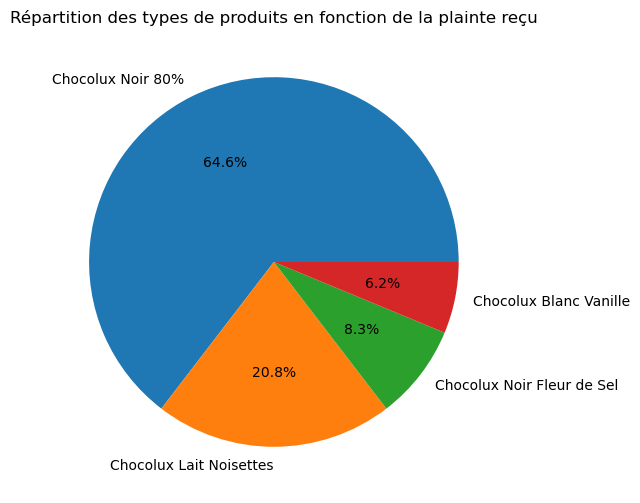

In [35]:
# Créer un graphique camembert des 4 produits les plus cités.

produit_4 = plaite_by_nom_produit_sorted.head(4)
plt.figure(figsize=(6,6))  
produit_4['plainte'].plot.pie(autopct='%1.1f%%') # On trace notre camembert en utilisant le comptage des type d'item
plt.title('Répartition des types de produits en fonction de la plainte reçu')
plt.ylabel('')
plt.show()

In [36]:
# Lister les villes avec le plus de plaintes par rapport aux commandes.
plaite_by_ville= df_nettoyage.groupby('ville',observed=False)[['plainte']].sum()
plaite_by_ville.sort_values('plainte', ascending=False)

# Les villes avec plus de plaintes sont paris et lille. 
# Ensuite, bordeaux et lyon ont aussi quelques plaintes. 

,plainte
ville,
paris,16
lille,12
bordeaux,7
lyon,5
marseille,4
nantes,2
nice,2
toulouse,0


---
# Question finale – Recommandations stratégiques
---

####  1. Produits à valoriser

Les deux produits les plus vendus en termes de quantité sont :

- Chocolux Lait Noisettes
- Chocolux Noir 80%

Par ailleurs, le chocolat noir domine dans les préférences de consommation des trois tranches d’âge (<25 ans, 25–45 ans, >45 ans).
Il est donc pertinent de valoriser davantage ces produits, notamment via des promotions ciblées ou une mise en avant sur les canaux de distribution. Leur fort potentiel de vente justifie une stratégie de valorisation prioritaire.

---

####  2. Produits à retravailler ou repositionner

Certains produits montrent des performances faibles :

Chocolux Lait Caramel : il génère un chiffre d’affaires faible et est acheté par peu de clients. Il pourrait être repositionné ou reformulé pour mieux correspondre aux attentes du marché.

Chocolat blanc (type de chocolat) : c’est le moins consommé par toutes les tranches d’âge. Une meilleure communication sur ses qualités, une reformulation ou un packaging plus attractif pourraient être envisagés, ou bien une réduction de sa place en rayon.

---

####  3. Villes et tranches d’âge à cibler en priorité
- Villes

Paris, Lille et Marseille sont les trois villes qui génèrent le plus de chiffre d’affaires.

Paris se distingue nettement : le montant des achats y est de deux à trois fois supérieur à celui des autres villes, toutes tranches d’âge confondues. Cela suggère un panier moyen plus élevé, ce qui en fait une zone stratégique à exploiter davantage.

- Tranches d’âge
 
Les 25–45 ans et les plus de 45 ans sont les deux segments les plus actifs en termes de volume d’achat et de chiffre d’affaires.

Les moins de 25 ans sont significativement moins consommateurs. Les efforts marketing peuvent donc se concentrer sur les tranches plus matures, plus rentables à court terme.

---

####  4. Fidélisation des clients à fort potentiel

Pour renforcer la fidélité des clients à fort pouvoir d’achat :

- Mettre en place des offres spéciales et promotions ciblées durant les périodes fortes telles que la Saint-Valentin, période où le chiffre d’affaires est historiquement le plus élevé.
- Déployer des campagnes de communication personnalisées en amont de ces événements pour capter l’attention des consommateurs fidèles.

---

####  5. Amélioration de la satisfaction client

L’analyse des plaintes montre une concentration autour de deux produits :

Chocolux Noir 80% : enregistre trois fois plus de plaintes que le Chocolux Lait Noisettes, bien qu’il soit le deuxième produit le plus vendu.

Ce produit étant très populaire auprès des clients de plus de 25 ans, il est stratégique de corriger les défauts signalés (qualité, emballage, goût, etc.). Cela pourrait améliorer la satisfaction tout en augmentant le chiffre d’affaires.

Villes concernées par les plaintes :

- Paris reçoit logiquement le plus de plaintes, étant aussi la ville avec le plus de ventes.
- En revanche, Lille enregistre un volume de plaintes élevé par rapport à son niveau de ventes, ce qui suggère des problèmes spécifiques à résoudre localement (qualité du service, logistique, etc.).

---

####  5. Recommandations globales

- Valoriser les produits phares (Chocolux Noir 80%, Lait Noisettes) tout en améliorant leur qualité perçue.

- Réviser ou repositionner les produits moins performants comme le Lait Caramel (nom de produit) et le chocolat blanc (type de produit) .

- Renforcer la présence commerciale et marketing à Paris, Lille et Marseille.

- Consolider la fidélité des tranches d’âge les plus rentables (25–45 ans et >45 ans).

- Cibler les périodes fortes, notamment la Saint-Valentin, pour des actions commerciales majeures.

- Mettre en place un plan qualité dans les villes avec un taux de plaintes élevé, en particulier Lille.